# Phase 3: Hidden State Extraction

This notebook runs the extraction of transformer hidden states for multiple models using the generated prompts dataset.

In [1]:
!git clone https://github.com/Vishal-sys-code/latent-trajectories.git

Cloning into 'latent-trajectories'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 97 (delta 37), reused 91 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 230.75 KiB | 7.69 MiB/s, done.
Resolving deltas: 100% (37/37), done.


In [2]:
%cd latent-trajectories

/content/latent-trajectories


In [3]:
%ls

data/  docs/  notebooks/  README.md  requirements.txt  scripts/  src/  tests/


In [4]:
%cd src

/content/latent-trajectories/src


In [5]:
%ls

extract_hidden_states.py  __init__.py      __pycache__/
extraction.py             load_prompts.py  trajectories.py
gitkeep.gitkeep           metrics.py       visualization.py


In [6]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.extract_hidden_states import run_extraction

## Run Extraction for GPT-2 Small
Baseline model for rapid iteration.

In [7]:
run_extraction(
    model_id="gpt2",
    model_name_short="gpt2",
    prompts_file="../data/prompts/prompts.jsonl",
    output_base_dir="../data/hidden_states",
    save_attentions=True
)

Loading model gpt2 on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded 50 prompts.


Extracting gpt2: 100%|██████████| 50/50 [00:01<00:00, 26.00it/s]


Saved metadata to ../data/hidden_states/gpt2/metadata.parquet
Saved 50 hidden state files to ../data/hidden_states/gpt2


## Run Extraction for TinyLlama 1.1B
Primary model for detailed layerwise analysis.

In [8]:
run_extraction(
    model_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    model_name_short="tinyllama",
    prompts_file="../data/prompts/prompts.jsonl",
    output_base_dir="../data/hidden_states",
    save_attentions=True
)

Loading model TinyLlama/TinyLlama-1.1B-Chat-v1.0 on cuda...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded 50 prompts.


Extracting tinyllama: 100%|██████████| 50/50 [00:04<00:00, 11.17it/s]

Saved metadata to ../data/hidden_states/tinyllama/metadata.parquet
Saved 50 hidden state files to ../data/hidden_states/tinyllama


## Run Extraction for Qwen 2.5 1.5B
Comparison model to test generalizability across architectures.

In [9]:
run_extraction(
    model_id="Qwen/Qwen2.5-1.5B",
    model_name_short="qwen",
    prompts_file="../data/prompts/prompts.jsonl",
    output_base_dir="../data/hidden_states",
    save_attentions=True
)

Loading model Qwen/Qwen2.5-1.5B on cuda...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Loaded 50 prompts.


Extracting qwen: 100%|██████████| 50/50 [00:05<00:00,  9.48it/s]


Saved metadata to ../data/hidden_states/qwen/metadata.parquet
Saved 50 hidden state files to ../data/hidden_states/qwen


## Validation
Let's perform a sanity check on the GPT-2 outputs to ensure they are shaped correctly and can be loaded.

--- Validation: GPT-2 ---
Total Prompts Extracted: 50
Model: gpt2
Layers: 13
Files Saved: 50

Sample 1 File: ../data/hidden_states/gpt2/analogy_001.pt
Tokens: ['King', ' :', ' Queen']
Hidden States Shape: torch.Size([13, 3, 768])
Last Token States Shape: torch.Size([13, 768])
Attentions Shape: torch.Size([12, 12, 3, 3])

Sample 2 File: ../data/hidden_states/gpt2/animal_008.pt
Tokens: ['The', ' dolphin', ' swim', 's', ' in', ' the', ' ocean', '.']
Hidden States Shape: torch.Size([13, 8, 768])
Last Token States Shape: torch.Size([13, 768])
Attentions Shape: torch.Size([12, 12, 8, 8])

Sample 3 File: ../data/hidden_states/gpt2/vehicle_006.pt
Tokens: ['The', ' vehicle', ' is', ' a', ' car', '.']
Hidden States Shape: torch.Size([13, 6, 768])
Last Token States Shape: torch.Size([13, 768])
Attentions Shape: torch.Size([12, 12, 6, 6])

Sample 4 File: ../data/hidden_states/gpt2/analogy_002.pt
Tokens: ['Man', ' :', ' Woman']
Hidden States Shape: torch.Size([13, 3, 768])
Last Token States Shape: 

/tmp/ipykernel_506/3522018662.py:59: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.tensor(layer_df["state"].tolist())
/tmp/ipykernel_506/3522018662.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  layer_df["pca1"] = X_pca[:, 0]
/tmp/ipykernel_506/3522018662.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#


Validation complete! PCA plot saved to data/hidden_states/gpt2_pca_validation.png


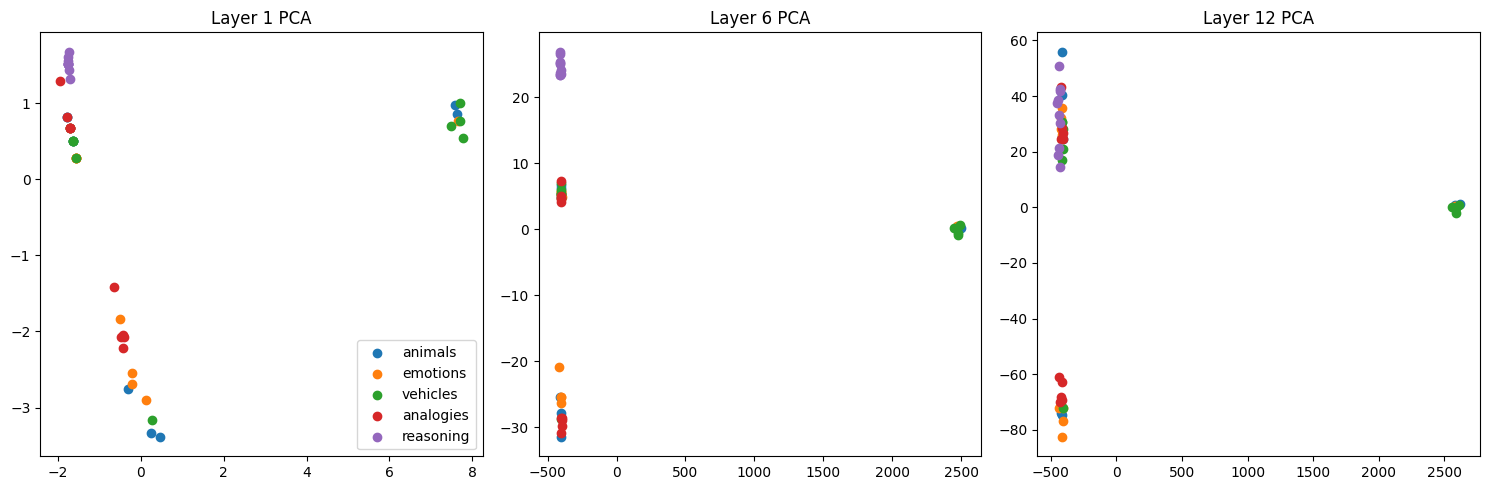

In [10]:
import torch
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import glob

print("--- Validation: GPT-2 ---")

# Load metadata
gpt2_metadata = pd.read_parquet("../data/hidden_states/gpt2/metadata.parquet")
print(f"Total Prompts Extracted: {len(gpt2_metadata)}")
print(f"Model: {gpt2_metadata.iloc[0]['model']}")
print(f"Layers: {gpt2_metadata.iloc[0]['num_layers']}")

pt_files = glob.glob("../data/hidden_states/gpt2/*.pt")
print(f"Files Saved: {len(pt_files)}")

# Select 5 random files
sample_files = random.sample(pt_files, 5)

for i, f in enumerate(sample_files):
    data = torch.load(f)
    print(f"\nSample {i+1} File: {f}")
    print(f"Tokens: {data['tokens']}")
    print(f"Hidden States Shape: {data['hidden_states'].shape}")
    print(f"Last Token States Shape: {data['last_token_states'].shape}")
    if 'attentions' in data:
        print(f"Attentions Shape: {data['attentions'].shape}")

# Simple PCA plot
# Let's take all last_token_states for all prompts for layers 1, 6, 12
layer_idx = [0, 5, 11] # 0-indexed: layer 1, 6, 12
all_data = []

for f in pt_files:
    data = torch.load(f)
    prompt_id = os.path.basename(f).split(".")[0]
    meta = gpt2_metadata[gpt2_metadata["prompt_id"] == prompt_id].iloc[0]
    category = meta["category"]

    last_states = data['last_token_states'] # [num_layers, hidden_dim]
    for l_idx in layer_idx:
        all_data.append({
            "layer": l_idx + 1,
            "category": category,
            "state": last_states[l_idx].numpy()
        })

df = pd.DataFrame(all_data)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, l in enumerate([1, 6, 12]):
    ax = axes[i]
    layer_df = df[df["layer"] == l]
    if len(layer_df) == 0:
        continue

    X = torch.tensor(layer_df["state"].tolist())
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    layer_df["pca1"] = X_pca[:, 0]
    layer_df["pca2"] = X_pca[:, 1]

    categories = layer_df["category"].unique()
    for cat in categories:
        cat_df = layer_df[layer_df["category"] == cat]
        ax.scatter(cat_df["pca1"], cat_df["pca2"], label=cat)

    ax.set_title(f"Layer {l} PCA")
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.savefig("../data/hidden_states/gpt2_pca_validation.png")
print("\nValidation complete! PCA plot saved to data/hidden_states/gpt2_pca_validation.png")